# Piloto de radiómica pancreática

**Proyecto:** Validación de un modelo predictivo multivariable a partir de las características radiómicas significativas de estudios tomográficos de pacientes con diagnóstico de adenocarcinoma ductal pancreático atendidos en el Hospital Nacional Guillermo Almenara Irigoyen entre enero de 2020 y junio de 2024.

**Alcance:** radiómica + machine learning; deep learning no forma parte del análisis principal.

**Objetivo:** ejecutar la corrida de punta a punta desde el CSV privado, sin cargar métricas previamente calculadas.

Según declaración del investigador, el proyecto previo presentado en San Marcos contó con aprobación ética y permisos del Almenara. Se consultó por el cambio de universidad y las modificaciones metodológicas; la versión actual debe volver a presentarse tras su aprobación por Ricardo Palma. La anonimización se realiza en el procesamiento de imágenes previo a esta tabla; este notebook no anonimiza DICOM. Fecha propuesta para completar recolección y procesamiento: 5 de diciembre de 2026, pendiente de aceptación.

In [1]:
# 1. Configuración: CAMBIAR SOLO ESTAS DOS RUTAS
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive_nuevo')

DATA = Path("/content/drive_nuevo/MyDrive/tesis 2/00 - ENTREGA PROFESOR 03-10-2026/01 - Notebook y codigo/radiomica_piloto_limpia_150.csv")

OUT = Path("/content/drive_nuevo/MyDrive/tesis 2/00 - ENTREGA PROFESOR 03-10-2026/01 - Notebook y codigo/resultados_publicos_03oct")

OUT.mkdir(parents=True, exist_ok=True)

print("DATA:", DATA)
print("Existe:", DATA.exists())
print("OUT:", OUT)

if not DATA.exists():
    raise FileNotFoundError(f"No se encontró el CSV en: {DATA}")

Mounted at /content/drive_nuevo
DATA: /content/drive_nuevo/MyDrive/tesis 2/00 - ENTREGA PROFESOR 03-10-2026/01 - Notebook y codigo/radiomica_piloto_limpia_150.csv
Existe: True
OUT: /content/drive_nuevo/MyDrive/tesis 2/00 - ENTREGA PROFESOR 03-10-2026/01 - Notebook y codigo/resultados_publicos_03oct


In [2]:
# 2. Librerías y semillas
import json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, brier_score_loss
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
SEEDS = [42, 123, 456, 789, 2026]
print("Semillas:", SEEDS)

Semillas: [42, 123, 456, 789, 2026]


## Etapa 1. Carga, auditoría de N y verificación de 1 paciente = 1 fila

In [3]:
df = pd.read_csv(DATA)

required = {"patient_id", "y"}
assert required.issubset(df.columns), f"Faltan columnas: {required-set(df.columns)}"
assert not df["patient_id"].duplicated().any(), "Hay patient_id duplicados."
assert len(df) == df["patient_id"].nunique(), "No se cumple 1 paciente = 1 fila."

exclude = {"patient_id", "seg_id", "y"}
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
y = df["y"].astype(int).to_numpy()
X = df[feature_cols]

audit = {
    "n_rows": len(df),
    "n_patients": df["patient_id"].nunique(),
    "n_positive": int(y.sum()),
    "n_negative": int((1-y).sum()),
    "positive_fraction": float(y.mean()),
    "n_numeric_features": len(feature_cols),
}
pd.DataFrame([audit])

,n_rows,n_patients,n_positive,n_negative,positive_fraction,n_numeric_features
0,150,150,89,61,0.593333,107


## Etapa 2. Pipeline: todo el preprocesamiento queda dentro del training

In [4]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        corr = Xdf.corr(method="spearman").abs()
        upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
        self.keep_idx_ = [i for i,c in enumerate(upper.columns) if not (upper[c] > self.threshold).any()]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.keep_idx_]

def metric_row(y, p, threshold=0.5):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return {
        "ROC_AUC": roc_auc_score(y,p),
        "PR_AUC": average_precision_score(y,p),
        "PR_baseline": float(np.mean(y)),
        "Balanced_Accuracy": balanced_accuracy_score(y,pred),
        "Precision": precision_score(y,pred,zero_division=0),
        "Sensitivity": recall_score(y,pred,zero_division=0),
        "Specificity": tn/(tn+fp),
        "F1": f1_score(y,pred,zero_division=0),
        "MCC": matthews_corrcoef(y,pred),
        "Brier": brier_score_loss(y,p),
    }

def make_pipeline(model):
    selector_est = LogisticRegression(
        penalty="l1", solver="liblinear", C=0.1,
        class_weight="balanced", max_iter=5000, random_state=42
    )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", RobustScaler()),
        ("corr", CorrelationFilter(0.90)),
        ("selector", SelectFromModel(selector_est, threshold=-np.inf, max_features=10)),
        ("model", model),
    ])

## Etapa 3. Tres modelos preespecificados y número de configuraciones

In [5]:
scale = max(1.0, int((y==0).sum()) / max(int((y==1).sum()),1))

models = {
    "ElasticNet_Logistic": (
        LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            class_weight="balanced", max_iter=6000, random_state=42
        ),
        {
            "selector__max_features":[5,10,20],
            "model__C":[0.1,1.0,3.0],
            "model__l1_ratio":[0.25,0.50,0.75],
        }
    ),
    "SVM_RBF": (
        SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
        {
            "selector__max_features":[5,10,20],
            "model__C":[0.5,1.0,2.0,4.0],
            "model__gamma":["scale",0.01,0.03],
        }
    ),
    "XGBoost": (
        XGBClassifier(
            n_estimators=150, eval_metric="logloss", random_state=42,
            n_jobs=1, tree_method="hist", scale_pos_weight=scale
        ),
        {
            "selector__max_features":[5,10,20],
            "model__max_depth":[2,3],
            "model__learning_rate":[0.03,0.10],
            "model__subsample":[0.8,1.0],
        }
    )
}

config_counts = {
    name: int(np.prod([len(v) for v in grid.values()]))
    for name,(_,grid) in models.items()
}
pd.DataFrame({"modelo":config_counts.keys(),
              "configuraciones_por_busqueda_interna":config_counts.values()})

,modelo,configuraciones_por_busqueda_interna
0,ElasticNet_Logistic,27
1,SVM_RBF,36
2,XGBoost,24


## Etapa 4. Repeated Nested Stratified 5-Fold CV

Cada repetición usa 5 folds externos. Dentro de cada training externo se ejecuta otra validación estratificada de 5 folds para selección/tuning. El test externo no participa en esas decisiones.

In [6]:
rows = []
params_rows = []
oof_all = {m:[] for m in models}

for model_name,(model,grid) in models.items():
    n_configs = config_counts[model_name]
    print(f"\n{model_name}: {n_configs} configuraciones por búsqueda interna")
    for run_idx,seed in enumerate(SEEDS,1):
        random.seed(seed); np.random.seed(seed)
        outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        p_oof = np.full(len(y), np.nan)

        for fold,(tr,te) in enumerate(outer.split(X,y),1):
            inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed+1000+fold)
            search = GridSearchCV(
                make_pipeline(clone(model)), grid,
                scoring="roc_auc", cv=inner, n_jobs=-1,
                refit=True, error_score="raise"
            )
            search.fit(X.iloc[tr], y[tr])

            calibrated = CalibratedClassifierCV(
                estimator=clone(search.best_estimator_),
                method="sigmoid", cv=3
            )
            calibrated.fit(X.iloc[tr], y[tr])
            p_oof[te] = calibrated.predict_proba(X.iloc[te])[:,1]

            params_rows.append({
                "model":model_name, "run":run_idx, "seed":seed, "fold":fold,
                "n_configurations":n_configs,
                "best_params_json":json.dumps(search.best_params_, sort_keys=True)
            })

        rows.append({"model":model_name, "run":run_idx, "seed":seed, **metric_row(y,p_oof)})
        oof_all[model_name].append(p_oof.copy())
        print(f"  run {run_idx}: ROC={roc_auc_score(y,p_oof):.4f} PR={average_precision_score(y,p_oof):.4f}")

metricas = pd.DataFrame(rows)
metricas


ElasticNet_Logistic: 27 configuraciones por búsqueda interna
  run 1: ROC=0.9133 PR=0.9317
  run 2: ROC=0.9024 PR=0.9152
  run 3: ROC=0.8956 PR=0.9060
  run 4: ROC=0.9092 PR=0.9278
  run 5: ROC=0.8946 PR=0.9202

SVM_RBF: 36 configuraciones por búsqueda interna
  run 1: ROC=0.9091 PR=0.9088
  run 2: ROC=0.9121 PR=0.9172
  run 3: ROC=0.9057 PR=0.9043
  run 4: ROC=0.9166 PR=0.9218
  run 5: ROC=0.9038 PR=0.9162

XGBoost: 24 configuraciones por búsqueda interna
  run 1: ROC=0.8835 PR=0.8999
  run 2: ROC=0.9038 PR=0.8914
  run 3: ROC=0.9075 PR=0.8967
  run 4: ROC=0.8920 PR=0.8854
  run 5: ROC=0.8972 PR=0.9072


,model,run,seed,ROC_AUC,PR_AUC,PR_baseline,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,MCC,Brier
0,ElasticNet_Logistic,1,42,0.913336,0.931682,0.593333,0.845460,0.868132,0.887640,0.803279,0.877778,0.694769,0.117608
1,ElasticNet_Logistic,2,123,0.902376,0.915183,0.593333,0.859274,0.879121,0.898876,0.819672,0.888889,0.722552,0.120897
2,ElasticNet_Logistic,3,456,0.895561,0.906034,0.593333,0.861853,0.887640,0.887640,0.836066,0.887640,0.723706,0.124591
3,ElasticNet_Logistic,4,789,0.909191,0.927767,0.593333,0.861853,0.887640,0.887640,0.836066,0.887640,0.723706,0.116452
4,ElasticNet_Logistic,5,2026,0.894640,0.920175,0.593333,0.853196,0.894118,0.853933,0.852459,0.873563,0.700228,0.126615
5,SVM_RBF,1,42,0.909099,0.908822,0.593333,0.886904,0.901099,0.921348,0.852459,0.911111,0.778119,0.109783
6,SVM_RBF,2,123,0.912139,0.917239,0.593333,0.864892,0.880435,0.910112,0.819672,0.895028,0.736117,0.110937
7,SVM_RBF,3,456,0.905692,0.904338,0.593333,0.862314,0.872340,0.921348,0.803279,0.896175,0.735896,0.116659
8,SVM_RBF,4,789,0.916559,0.921761,0.593333,0.873089,0.890110,0.910112,0.836066,0.900000,0.750336,0.105707
9,SVM_RBF,5,2026,0.903850,0.916164,0.593333,0.853656,0.877778,0.887640,0.819672,0.882682,0.709209,0.116449


## Etapa 5. Media ± DE: estabilidad entre las cinco repeticiones

In [7]:
resumen = metricas.groupby("model").agg(
    N_runs=("run","count"),
    ROC_AUC_mean=("ROC_AUC","mean"), ROC_AUC_sd=("ROC_AUC","std"),
    PR_AUC_mean=("PR_AUC","mean"), PR_AUC_sd=("PR_AUC","std"),
    Sensitivity_mean=("Sensitivity","mean"),
    Specificity_mean=("Specificity","mean"),
    Brier_mean=("Brier","mean"),
    MCC_mean=("MCC","mean"),
).reset_index()
resumen

,model,N_runs,ROC_AUC_mean,ROC_AUC_sd,PR_AUC_mean,PR_AUC_sd,Sensitivity_mean,Specificity_mean,Brier_mean,MCC_mean
0,ElasticNet_Logistic,5,0.903021,0.008228,0.920168,0.010185,0.883146,0.829508,0.121233,0.712992
1,SVM_RBF,5,0.909468,0.005084,0.913665,0.006982,0.910112,0.826230,0.111907,0.741935
2,XGBoost,5,0.896795,0.009541,0.896092,0.008278,0.907865,0.806557,0.114320,0.722139


## Etapa 6. IC95% bootstrap sobre la probabilidad OOF promedio

El bootstrap cuantifica la incertidumbre de las métricas **sin volver a entrenar el pipeline**. Esta limitación queda declarada en el reporte.

In [8]:
def bootstrap_ci(y,p,B=2000,seed=2026):
    rng=np.random.default_rng(seed)
    pos=np.where(y==1)[0]; neg=np.where(y==0)[0]
    vals={"ROC_AUC":[],"PR_AUC":[],"Brier":[]}
    for _ in range(B):
        idx=np.concatenate([
            rng.choice(pos,len(pos),replace=True),
            rng.choice(neg,len(neg),replace=True)
        ])
        yy=y[idx]; pp=p[idx]
        vals["ROC_AUC"].append(roc_auc_score(yy,pp))
        vals["PR_AUC"].append(average_precision_score(yy,pp))
        vals["Brier"].append(brier_score_loss(yy,pp))
    out={}
    for k,v in vals.items():
        out[k+"_CI_low"],out[k+"_CI_high"]=np.percentile(v,[2.5,97.5])
    return out

ci_rows=[]
for model_name,plist in oof_all.items():
    pmean=np.mean(np.vstack(plist),axis=0)
    point=metric_row(y,pmean)
    ci=bootstrap_ci(y,pmean)
    ci_rows.append({
        "model":model_name,
        "ROC_AUC":point["ROC_AUC"], "ROC_AUC_CI_low":ci["ROC_AUC_CI_low"], "ROC_AUC_CI_high":ci["ROC_AUC_CI_high"],
        "PR_AUC":point["PR_AUC"], "PR_AUC_CI_low":ci["PR_AUC_CI_low"], "PR_AUC_CI_high":ci["PR_AUC_CI_high"],
        "Brier":point["Brier"], "Brier_CI_low":ci["Brier_CI_low"], "Brier_CI_high":ci["Brier_CI_high"],
    })
ic95 = pd.DataFrame(ci_rows)
ic95

,model,ROC_AUC,ROC_AUC_CI_low,ROC_AUC_CI_high,PR_AUC,PR_AUC_CI_low,PR_AUC_CI_high,Brier,Brier_CI_low,Brier_CI_high
0,ElasticNet_Logistic,0.906981,0.852454,0.953781,0.925391,0.873829,0.967546,0.117319,0.092433,0.145017
1,SVM_RBF,0.915822,0.860379,0.962056,0.913124,0.840453,0.973885,0.108108,0.081930,0.138430
2,XGBoost,0.900166,0.832377,0.953960,0.893660,0.816194,0.964473,0.109452,0.083353,0.138605


## Etapa 7. Figuras actualizadas

Gráficos regenerados desde las tablas agregadas de esta corrida guardadas en el notebook; no se volvió a entrenar el modelo para este cambio visual. Sin sello de IPRIAS ni afirmaciones causales sobre fuga.


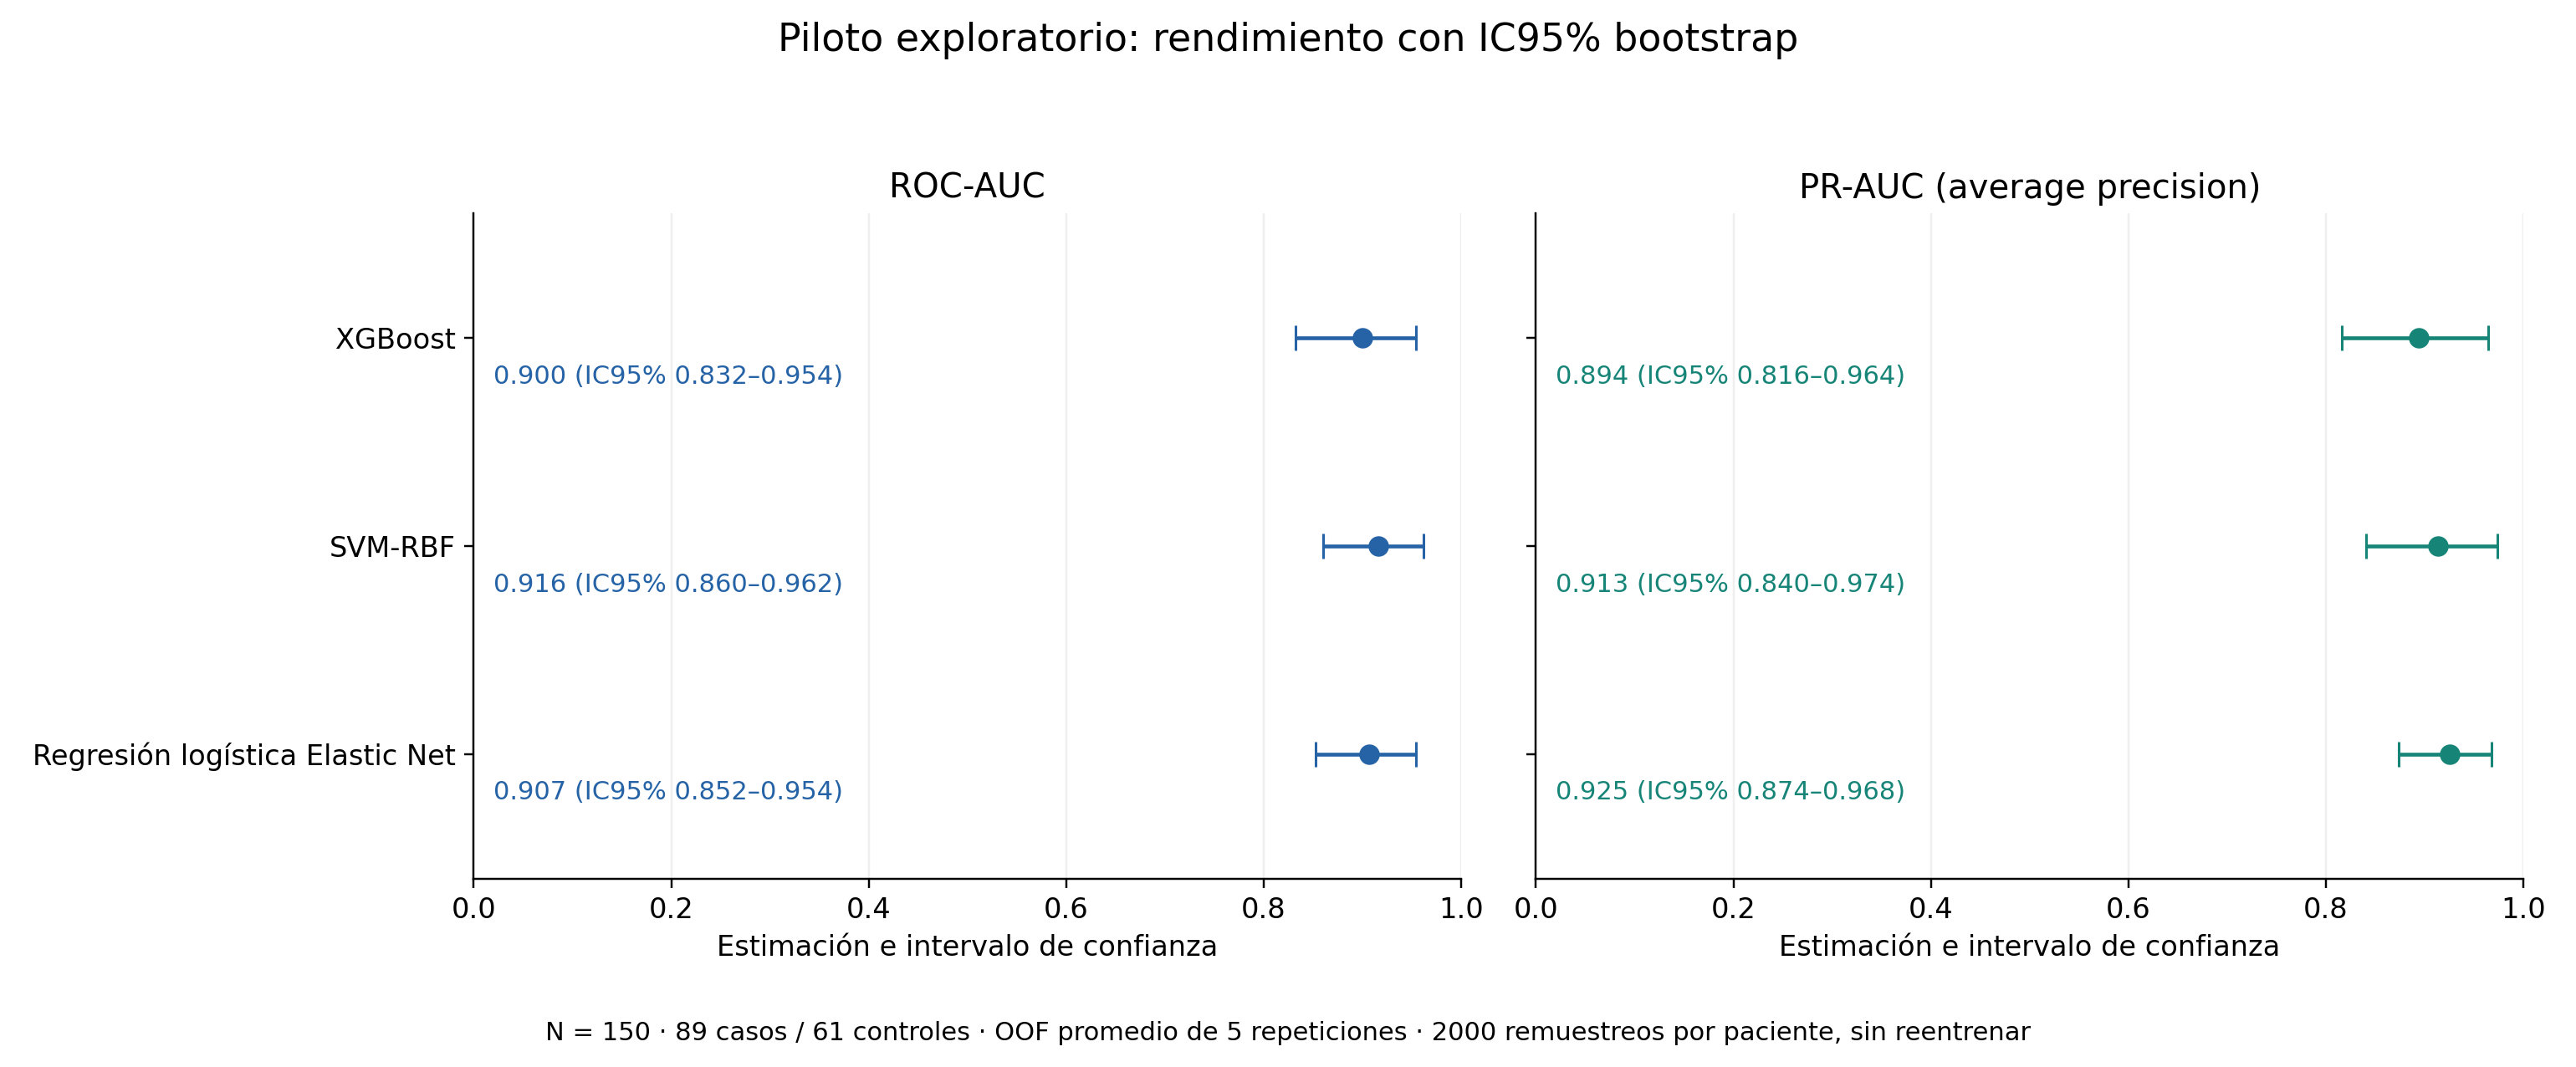

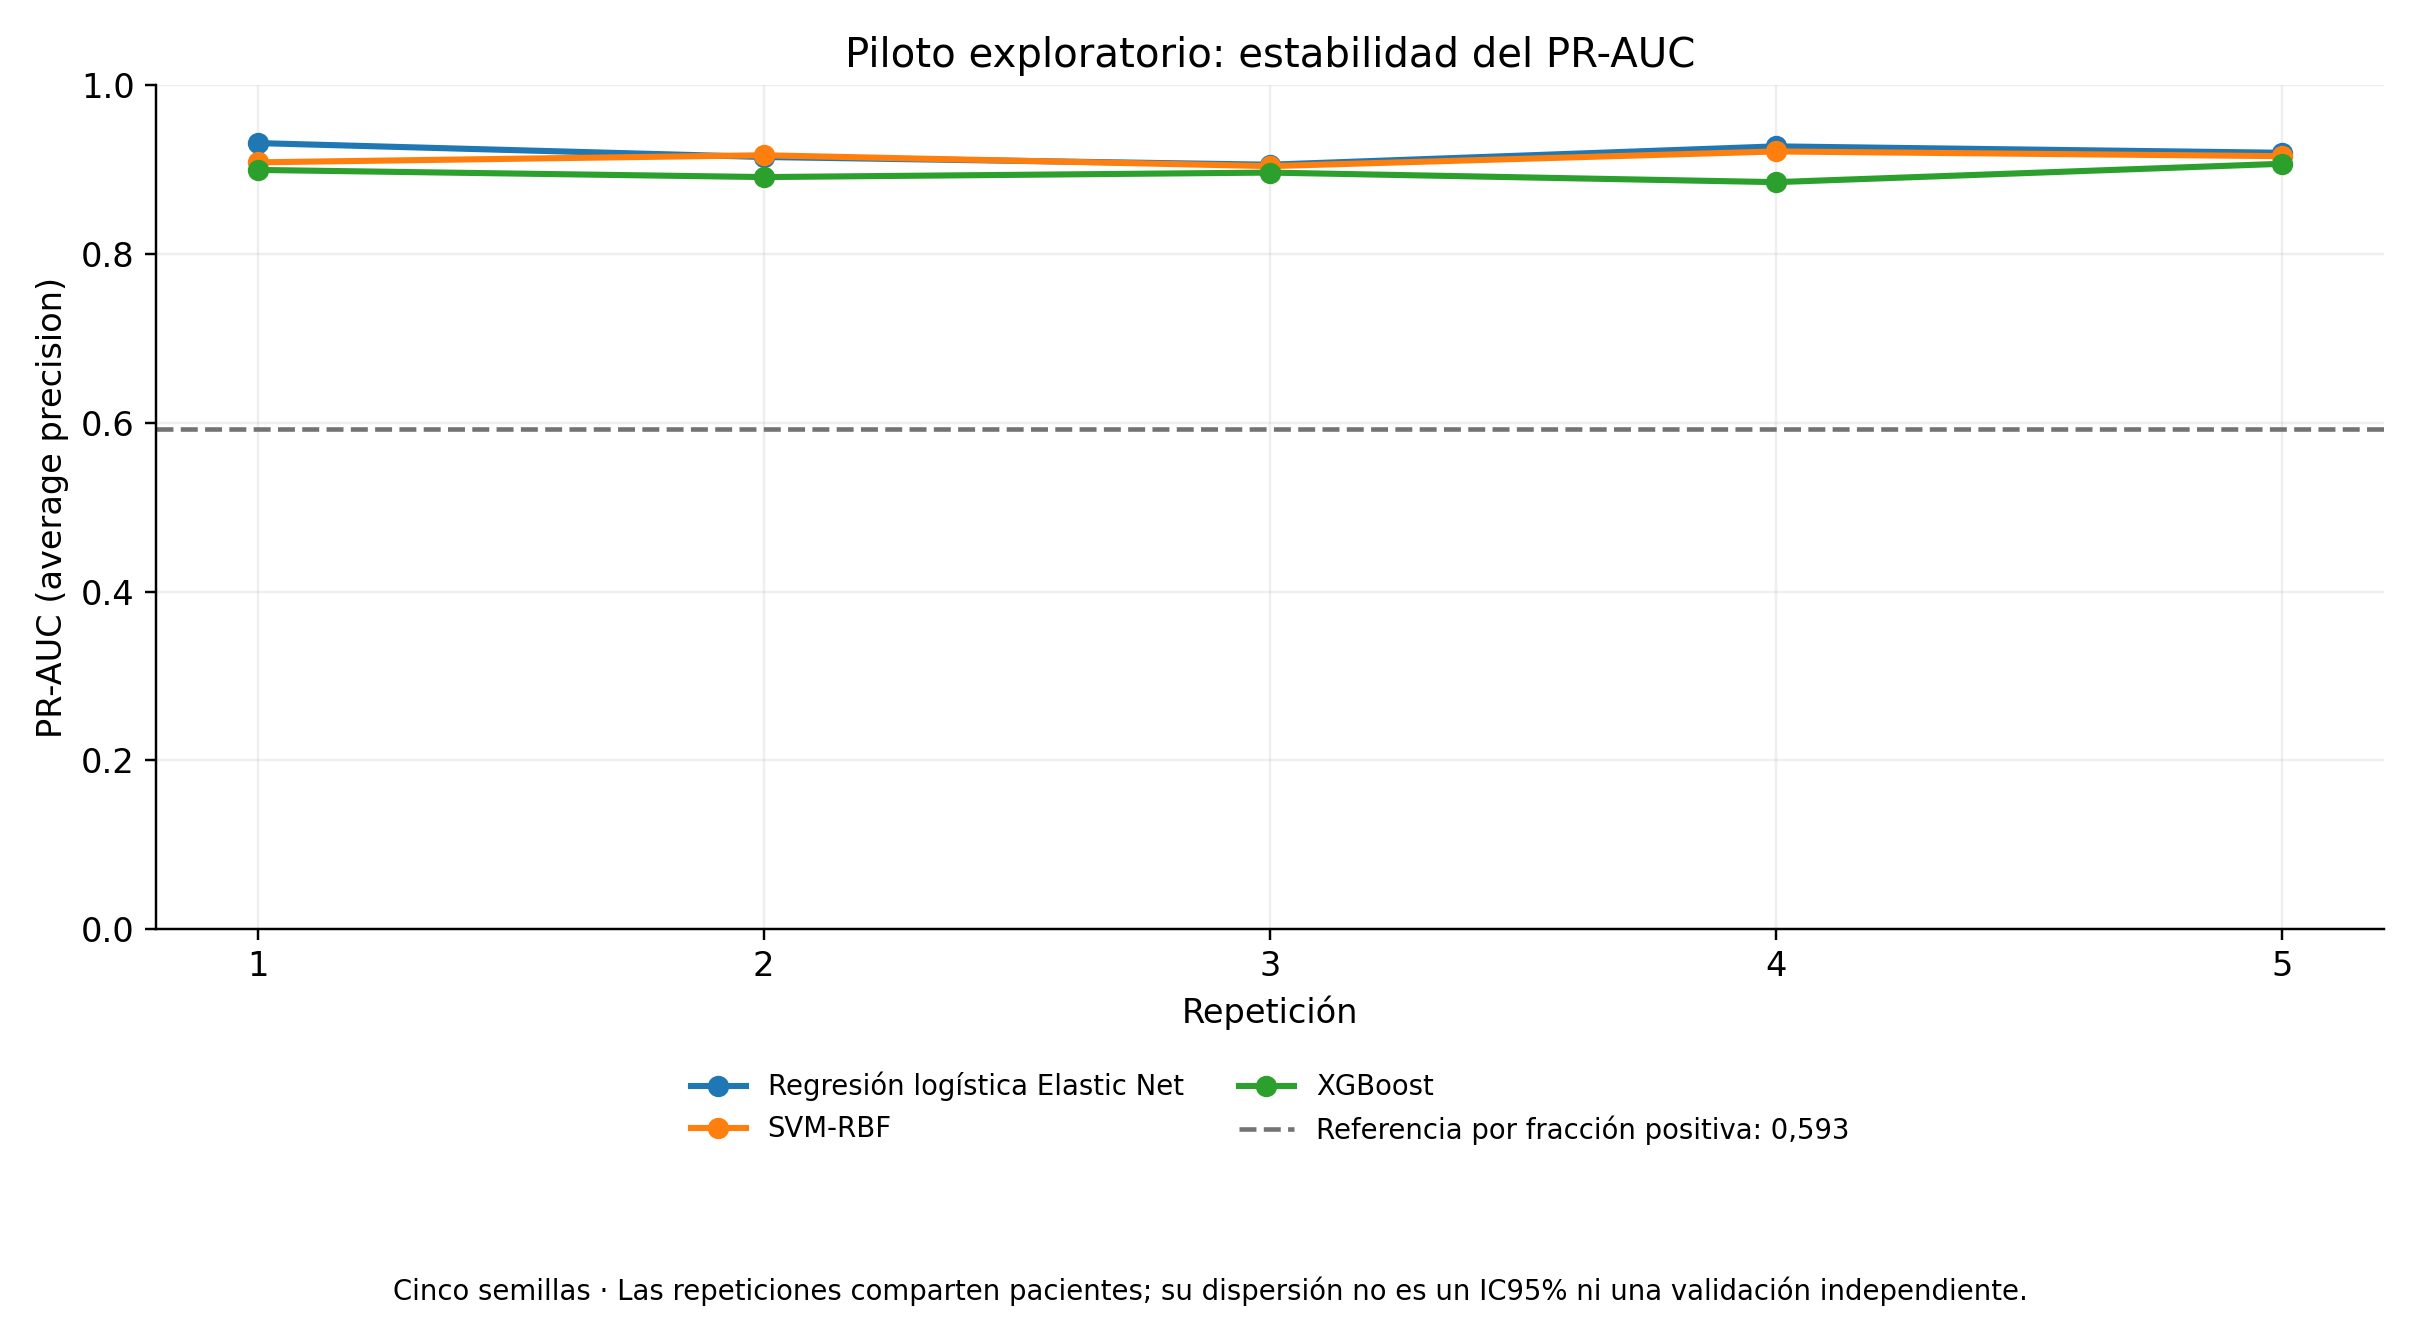

In [9]:
FIGS = OUT / "figures"
FIGS.mkdir(exist_ok=True)
labels = {"ElasticNet_Logistic": "Regresión logística Elastic Net", "SVM_RBF": "SVM-RBF", "XGBoost": "XGBoost"}
plt.rcParams.update({"font.size": 11})
# Figura 1: IC95% condicional, sin reentrenamiento.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharey=True)
yy = np.arange(len(ic95))
for ax, metric, color in zip(axes, ["ROC_AUC", "PR_AUC"], ["#2563A6", "#168578"]):
    est = ic95[metric].to_numpy()
    low = ic95[metric + "_CI_low"].to_numpy()
    high = ic95[metric + "_CI_high"].to_numpy()
    ax.errorbar(est, yy, xerr=[est-low, high-est], fmt="o", color=color, capsize=5, markersize=7)
    for j, (v, lo, hi) in enumerate(zip(est, low, high)):
        ax.text(.02, j-.22, f"{v:.3f} (IC95% {lo:.3f}–{hi:.3f})", fontsize=10, color=color)
    ax.set_xlim(0, 1); ax.set_ylim(-.6, len(ic95)-.4)
    ax.set_title("ROC-AUC" if metric == "ROC_AUC" else "PR-AUC (average precision)")
    ax.set_xlabel("Estimación e intervalo de confianza")
    ax.grid(axis="x", alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_yticks(yy, [labels.get(x,x) for x in ic95.model])
fig.suptitle("Piloto exploratorio: rendimiento con IC95% bootstrap", fontsize=15)
fig.text(.5,.025,"N = 150 · 89 casos / 61 controles · OOF promedio de 5 repeticiones · 2000 remuestreos por paciente, sin reentrenar",ha="center",fontsize=10)
fig.tight_layout(rect=[0,.07,1,.93])
fig.savefig(FIGS/"Figura_1_Rendimiento_IC95.png", dpi=220)
plt.show()
# Figura 2: estabilidad; las repeticiones comparten pacientes.
fig,ax=plt.subplots(figsize=(11,6))
for name,d in metricas.groupby("model",sort=False):
    z=d.sort_values("run")
    ax.plot(z.run,z.PR_AUC,marker="o",linewidth=2,label=labels.get(name,name))
ax.axhline(89/150,linestyle="--",color="#737373",label="Referencia por fracción positiva: 0,593")
ax.set_ylim(0,1);ax.set_xticks([1,2,3,4,5]);ax.set_xlabel("Repetición");ax.set_ylabel("PR-AUC (average precision)")
ax.set_title("Piloto exploratorio: estabilidad del PR-AUC")
ax.legend(loc="upper center",bbox_to_anchor=(.5,-.14),ncol=2,frameon=False,fontsize=9)
ax.grid(alpha=.2);ax.spines[["top","right"]].set_visible(False)
fig.text(.5,.015,"Cinco semillas · Las repeticiones comparten pacientes; su dispersión no es un IC95% ni una validación independiente.",ha="center",fontsize=9)
fig.tight_layout(rect=[0,.08,1,1])
fig.savefig(FIGS/"Figura_2_Estabilidad_PR_AUC.png",dpi=220)
plt.show()


## Etapa 8. Guardar únicamente resultados agregados

No se exportan `patient_id`, `seg_id` ni predicciones fila por fila a la carpeta pública.

In [10]:
metricas.to_csv(OUT/"metricas_5_corridas.csv",index=False)
resumen.to_csv(OUT/"resumen_modelos.csv",index=False)
ic95.to_csv(OUT/"bootstrap_IC95.csv",index=False)
pd.DataFrame(params_rows).to_csv(OUT/"hiperparametros_por_fold.csv",index=False)
(OUT/"dataset_audit.json").write_text(json.dumps(audit,indent=2),encoding="utf-8")

print("Archivos generados:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(OUT))

Archivos generados:
 - bootstrap_IC95.csv
 - dataset_audit.json
 - figures/Figura_1_Rendimiento_IC95.png
 - figures/Figura_2_Estabilidad_PR_AUC.png
 - hiperparametros_por_fold.csv
 - metricas_5_corridas.csv
 - resumen_modelos.csv


## Nota de interpretación

El valor histórico **PR-AUC = 0,965** se conserva únicamente como antecedente del README original. Esta corrida no intenta atribuir todavía la diferencia a una causa concreta; la comparación controlada de la caída del PR-AUC se realizará posteriormente cambiando un solo componente del procedimiento por vez.